# Summary analysis for ongoing selection


- For this to work, you need to adapt the folder where raw data and metaData live.
- Also, you need to clone the jlsocialbehavior repository and create the environment jlsocial from the yml file.

In [ ]:
import os

#define folders

# base = 'Y://Johannes//b//2019//' This is the original base folder where the meta data was stored
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/'  # Updated base folder. Metadata should live here.
codeDir = 'C:/Users/crodri19/OneDrive - Université de Lausanne/LarschPostDoc/analyses/selection_shoaling/jlsocialbehavior/' #adapt this to your code folder
metaFile='MetaData_CR.xlsx'
ProcessingDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_processing/'
outputDir = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp/shoaling_selection/ShoalSelec_temp_output/'

print('searching for meta info here: ' + metaFolder)

os.chdir(codeDir)

searching for meta info here: //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_data/


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.stats.api as sms

%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
import fnmatch

import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
import glob
#import h5py
from datetime import datetime
import PythonMeta as PMA
from matplotlib.ticker import AutoLocator

import functions.matrixUtilities_joh as mu
import functions.notebookHelper as nh
import functions.metaTree as mt

import models.experiment as xp
import models.experiment_set as es
import functions.paperFigureProps as pfp
pfp.paper()

using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


In [3]:
# Check if the meta folder exists and list files
#files = os.listdir('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/Carlos/shoaling_assay_data/')
#print(files)

info=pd.read_excel(metaFolder+metaFile, sheet_name='AllExp')
info

,expNr,date,stimulusProtocol,set,path,folder,setup,anNr,first_anNR,first_anNR.1,hi_tanks,lo_tanks
0,1,28-01-2025,original,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250128_01_35Animals_dn_TLSel1F9,1,1:35,1,35,"L192,L191","L188,L189"
1,2,13-05-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250513_01_35Animals_s1_TLSel3F7,1,36:70,36,70,"L339,L314,L315,L320,","L340,L316,L317,L319"
2,3,13-05-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250513_02_35Animals_s2_TLSel3F7,2,71:105,71,105,"L339,L314,L315,L320,","L340,L316,L317,L320"
3,4,18-06-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250618_01_35Animals_s1_TLSel1F10,1,106:140,106,140,"L393,L368,L369","L394,L370,L371"
4,5,18-06-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250618_02_35Animals_s2_TLSel1F10,2,141:175,141,175,"L393,L368,L370","L394,L370,L372"
5,6,01-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250701_01_35Animals_s1_TLSel1GC,1,176:210,176,210,"L386,L387","L384,L385"
6,7,01-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250701_02_35Animals_s2_TLSel1GC,2,211:245,211,245,"L386,L387","L384,L385"
7,8,28-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250728_01_35Animals_s1_TLSel1F10,1,246:280,246,280,"L440,L420,L421","L441,L422,L423"
8,9,28-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250728_02_35Animals_s2_TLSel1F10,2,281:315,281,315,"L440,L420,L422","L441,L422,L424"
9,10,29-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250729_01_35Animals_s1_TLSel3F8,1,316:350,316,350,"L442,L416,L417","L443,L418,L419"


In [4]:
# infoAn=pd.read_excel(metaFolder+metaFile, sheet_name='AllAn',parse_dates=['bd','expDate'])
# infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%Y%m%d')
# infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%Y%m%d')
# infoAn.tail()

infoAn = pd.read_excel(metaFolder + metaFile, sheet_name='AllAn')
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%d-%m-%Y', dayfirst=True)
infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%d-%m-%Y', dayfirst=True)
infoAn.tail()

,anNr,line,genotype,cohort,bd,expNr,expDate,anexpID,anLabID,coordinates
485,486,Sel3_7,lo,na,2025-08-14,14,2025-09-01,31,L454_f33,E3
486,487,Sel3_7,hi,na,2025-08-14,14,2025-09-01,32,L457_f34,E4
487,488,Sel3_7,lo,na,2025-08-14,14,2025-09-01,33,L454_f34,E5
488,489,Sel3_7,hi,na,2025-08-14,14,2025-09-01,34,L457_f35,E6
489,490,Sel3_7,lo,na,2025-08-14,14,2025-09-01,35,L454_f35,E7


In [5]:
infoAn.genotype.unique()

array(['hi', 'lo', 'esc_lo', 'esc_hi', 'na'], dtype=object)

In [6]:
# collect meta information and save to new csv file for batch processing

aviPath=[]
posPath=[]
PLPath=[]
expTime = []
birthDayAll=[]
anIDsAll=[]
camHeightAll=[]

camHeight=[105,180] # these are outdated values, but we keep them for compatibility with old data

for index,row in info.iterrows():

    startDir=row.path+'\\'+row.folder+'\\'
    print('processing: ' + startDir)
    if not os.path.exists(startDir):
        print('WARNING: path does not exist: ' + startDir)
        continue

    
    posPath.append(glob.glob(startDir+'PositionTxt*')[0]) #this is the trajectory file
    PLPath.append(glob.glob(startDir+'PL*')[0]) # this is the pair list file
    
    head, tail = os.path.split(posPath[-1])
    currTime='dummy' #datetime.strptime(tail[-23:-4], '%Y-%m-%dT%H_%M_%S')
    expTime.append(currTime)
    
    camHeightAll.append(camHeight[('_dn_' in head)*1]) ######### this needs to be adapted for new data, since the camHeight is not stored in the meta data anymore.
    
    anNrs=row.anNr #Note that anNrs are 1 based!
    if ':' in anNrs:
        a,b=anNrs.split(sep=':')
        anNrs=np.arange(int(a),int(b)+1)
    else:
        anNrs=np.array(anNrs.split()).astype(int)
        
    anIDs=anNrs #-1 no more 0-based since using pandas merge to find animal numbers
    anIDsAll.extend(anIDs)

    bd=infoAn[infoAn.anNr.isin(anIDs)].bd.values.astype(str) # get birth dates of animals in this experiment
    #bd=infoAn.bd.values[anIDs-1] #a bit dirty to use anIDs directly here. Should merge
    birthDayAll.append(' '.join(list(bd)))

info['camHeight']=camHeightAll
info['txtPath']=posPath
info['pairList']=PLPath
info['aviPath']='default'
info['birthDayAll']=birthDayAll
info['epiDur'] = 5      # duration of individual episodes (default: 5 minutes)
info['episodes'] = 24   # number of episodes to process: -1 to load all episodes (default: -1)
info['inDish'] = 10#np.arange(len(posPath))*120     # time in dish before experiments started (default: 10)
info['arenaDiameter_mm'] = 70 # arena diameter (default: 100 mm)
info['minShift'] = 60 # minimum number of seconds to shift for control IAD
info['episodePLcode'] = 0 # flag if first two characters of episode name encode animal pair matrix (default: 0)
info['recomputeAnimalSize'] = 0 # flag to compute animals size from avi file (takes time, default: 1)
info['SaveNeighborhoodMaps'] = 0 # flag to save neighborhood maps for subsequent analysis (takes time, default: 1)
info['computeLeadership'] = 0 # flag to compute leadership index (takes time, default: 1)
info['ComputeBouts'] = 1 # flag to compute swim bout frequency (takes time, default: 1)
#info['set'] = np.arange(len(posPath))   # experiment set: can label groups of experiments (default: 0)
info['ProcessingDir']=ProcessingDir
info['outputDir']=outputDir
info['expTime']=expTime
info['readLim'] = 24*5*60*30+11

processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250128_01_35Animals_dn_TLSel1F9\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250513_01_35Animals_s1_TLSel3F7\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250513_02_35Animals_s2_TLSel3F7\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250618_01_35Animals_s1_TLSel1F10\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250618_02_35Animals_s2_TLSel1F10\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250701_01_35Animals_s1_TLSel1GC\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250701_02_35Animals_s2_TLSel1GC\
processing: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\Carlos\shoaling_data\20250728_

In [7]:
csvFile=os.path.join(ProcessingDir,'processingSettings.csv')
info.to_csv(csvFile,encoding='utf-8')
info.tail()

,expNr,date,stimulusProtocol,set,path,folder,setup,anNr,first_anNR,first_anNR.1,...,minShift,episodePLcode,recomputeAnimalSize,SaveNeighborhoodMaps,computeLeadership,ComputeBouts,ProcessingDir,outputDir,expTime,readLim
9,10,29-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250729_01_35Animals_s1_TLSel3F8,1,316:350,316,350,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
10,11,29-07-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250729_02_35Animals_s2_TLSel3F8,2,351:385,351,385,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
11,12,05-08-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250805_01_35Animals_s1_TLSel3F7,1,386:420,386,420,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
12,13,01-09-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250901_01_35Animals_s1_TLSel3F7,1,421:455,421,455,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011
13,14,01-09-2025,short,NaN,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,20250901_02_35Animals_s2_TLSel3F7,2,456:490,456,490,...,60,0,0,0,0,1,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsc...,dummy,216011


In [8]:
rereadData=1
if rereadData:
    def readExperiment(keepData=True):
        tmp=es.experiment_set(csvFile=csvFile,MissingOnly=True)
        if keepData:
            return tmp
        else:
            return 1

    expSet=readExperiment(keepData=False)

False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionTxt_allROI2025-01-28T12_37_44*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionTxt_allROI2025-05-13T12_12_02*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionTxt_allROI2025-05-13T12_12_59*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionTxt_allROI2025-06-18T10_56_01*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionTxt_allROI2025-06-18T10_54_26*siSummary*.csv
False False //nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing//PositionT

In [9]:
csvPath = []
for f in [mu.splitall(x)[-1][:-4] for x in info.txtPath]:
    csvPath.append(glob.glob(ProcessingDir+f+'*siSummary*.csv')[0])

df=pd.DataFrame()
i=0
for fn in csvPath:
    print(fn)
    tmp=pd.read_csv(fn,index_col=0,sep=',')
    tmp.animalSet=i
    tmp.animalIndex=tmp.animalIndex+((i)*35)
    tmp.animalIndex=np.array(anIDsAll)[tmp.animalIndex]
    df=pd.concat([df,tmp])
    i+=1
df['episode']=[x.strip().replace('_','') for x in df['episode']]
df=pd.merge(df,infoAn[['anNr','line','genotype']],left_on='animalIndex',right_on='anNr',how='left')
df=pd.merge(df,info[['date']],left_on='animalSet',right_on=info.index,how='left')
df['setup'] = info['setup'].values[df['animalSet'].values]
print('df shape',df.shape)
df['lineSet']=[x+'_'+y for x,y in zip(df.line, df.date)]


df.tail(10)

//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-01-28T12_37_44_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-05-13T12_12_02_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-05-13T12_12_59_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-06-18T10_56_01_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-06-18T10_54_26_siSummary_epi5.0.csv
//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_processing\PositionTxt_allROI2025-07-01T10_46_10_siSummary_epi5.0.cs

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,boutDur,leadershipIndex,sync_amp,sync_t,anNr,line,genotype,date,setup,lineSet
11750,13,481,25,35,0.055843,02k20f,207000,125.0,23,125.0,...,0.900000,0,0,0,481,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11751,13,482,26,35,0.259512,02k20f,207000,125.0,23,125.0,...,0.833333,0,0,0,482,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11752,13,483,27,35,0.303802,02k20f,207000,125.0,23,125.0,...,0.933333,0,0,0,483,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11753,13,484,28,35,0.497876,02k20f,207000,125.0,23,125.0,...,0.900000,0,0,0,484,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11754,13,485,29,35,0.151957,02k20f,207000,125.0,23,125.0,...,1.133333,0,0,0,485,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11755,13,486,30,35,0.223317,02k20f,207000,125.0,23,125.0,...,0.766667,0,0,0,486,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11756,13,487,31,35,0.105950,02k20f,207000,125.0,23,125.0,...,0.866667,0,0,0,487,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11757,13,488,32,35,0.105791,02k20f,207000,125.0,23,125.0,...,0.700000,0,0,0,488,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11758,13,489,33,35,0.115824,02k20f,207000,125.0,23,125.0,...,0.900000,0,0,0,489,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11759,13,490,34,35,0.225400,02k20f,207000,125.0,23,125.0,...,0.833333,0,0,0,490,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025


In [10]:
df.tail(40)

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,boutDur,leadershipIndex,sync_amp,sync_t,anNr,line,genotype,date,setup,lineSet
11720,13,486,30,35,0.324947,01k01f,198000,120.0,22,120.0,...,0.800000,0,0,0,486,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11721,13,487,31,35,0.059823,01k01f,198000,120.0,22,120.0,...,0.800000,0,0,0,487,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11722,13,488,32,35,0.058804,01k01f,198000,120.0,22,120.0,...,0.766667,0,0,0,488,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11723,13,489,33,35,0.094667,01k01f,198000,120.0,22,120.0,...,0.900000,0,0,0,489,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11724,13,490,34,35,0.162472,01k01f,198000,120.0,22,120.0,...,0.733333,0,0,0,490,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11725,13,456,0,35,0.220043,02k20f,207000,125.0,23,125.0,...,0.600000,0,0,0,456,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11726,13,457,1,35,0.164032,02k20f,207000,125.0,23,125.0,...,0.866667,0,0,0,457,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11727,13,458,2,35,0.503199,02k20f,207000,125.0,23,125.0,...,0.783333,0,0,0,458,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025
11728,13,459,3,35,0.278747,02k20f,207000,125.0,23,125.0,...,1.166667,0,0,0,459,Sel3_7,hi,01-09-2025,2,Sel3_7_01-09-2025
11729,13,460,4,35,0.199403,02k20f,207000,125.0,23,125.0,...,0.866667,0,0,0,460,Sel3_7,lo,01-09-2025,2,Sel3_7_01-09-2025


In [11]:
sns.set_palette('viridis',3)
co=sns.color_palette("viridis", 3)
idx=(df['inDishTime']<240) & (df['inDishTime']>80)
dfDR=df[idx]
dfEpiAn=dfDR.groupby(['episode','animalIndex','line','setup','genotype','date','lineSet'],sort=True).mean(numeric_only=True).reset_index()

In [12]:
dfEpiAn.head()

,episode,animalIndex,line,setup,genotype,date,lineSet,animalSet,animalID,CurrentPartner,...,age,avgSpeed,avgSpeed_smooth,anSize,thigmoIndex,boutDur,leadershipIndex,sync_amp,sync_t,anNr
0,01k01f,1,TLSel1_9,1,hi,28-01-2025,TLSel1_9_28-01-2025,0.0,0.0,35.0,...,0.0,4.848335,3.506125,0.0,16.412777,1.050000,0.0,0.0,0.0,1.0
1,01k01f,2,TLSel3_7,1,lo,28-01-2025,TLSel3_7_28-01-2025,0.0,1.0,35.0,...,0.0,5.154886,3.990182,0.0,14.116115,1.100000,0.0,0.0,0.0,2.0
2,01k01f,3,TLSel1_9,1,hi,28-01-2025,TLSel1_9_28-01-2025,0.0,2.0,35.0,...,0.0,5.399696,4.095942,0.0,17.472203,1.008333,0.0,0.0,0.0,3.0
3,01k01f,4,TLSel3_7,1,lo,28-01-2025,TLSel3_7_28-01-2025,0.0,3.0,35.0,...,0.0,5.185583,3.812896,0.0,17.307637,0.970833,0.0,0.0,0.0,4.0
4,01k01f,5,TLSel1_9,1,hi,28-01-2025,TLSel1_9_28-01-2025,0.0,4.0,35.0,...,0.0,3.580762,2.070623,0.0,18.405473,1.116667,0.0,0.0,0.0,5.0


In [13]:

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x))

x=np.random.random(100)

def ci95(x):
    return np.nanmean(x)-sms.DescrStatsW(x[np.isfinite(x)]).tconfint_mean()[0]

print('std of uniform = 0.2886751345948129. STDdata:',np.std(x), 'semData:',sem(x),'samples:',x.shape) 
print('ci95:',ci95(x))

std of uniform = 0.2886751345948129. STDdata: 0.305523926868957 semData: 0.030706309996979188 samples: (100,)
ci95: 0.06092798081428663


In [14]:
dfPlot=(df.groupby(['inDishTime','episode','genotype','lineSet']).si.agg(['mean','std',sem,ci95])
    .unstack()
    .stack(dropna=True)
    .reset_index())

dfPlot.head()

c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:228: RuntimeWarning: invalid value encountered in scalar divide
  return std / np.sqrt(self.sum_weights - 1)
C:\Users\crodri19\AppData\Local\Temp\ipykernel_18056\2785734730.py:7: RuntimeWarning: Mean of empty slice
  return np.nanmean(x)-sms.DescrStatsW(x[np.isfinite(x)]).tconfint_mean()[0]
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:135: RuntimeWarning: invalid value encountered in scalar divide
  return self.sum / self.sum_weights
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:182: RuntimeWarning: invalid value encountered in scalar divide
  return self.sumsquares / (self.sum_weights - self.ddof)
c:\Users\crodri19\AppData\Local\miniconda3\envs\jlsocial\Lib\site-packages\statsmodels\stats\weightstats.py:228: RuntimeWarning: invalid value encountered in sqr

,inDishTime,episode,genotype,lineSet,mean,std,sem,ci95
0,10.0,01k01f,esc_hi,Sel1_10_18-06-2025,0.333052,0.146631,0.103684,1.317430
1,10.0,01k01f,esc_hi,Sel1_GC_01-07-2025,-0.022984,0.088838,0.036268,0.093229
2,10.0,01k01f,esc_hi,Sel3_7_01-09-2025,-0.003670,NaN,NaN,NaN
3,10.0,01k01f,esc_lo,Sel1_10_18-06-2025,0.015411,0.028363,0.016375,0.070457
4,10.0,01k01f,esc_lo,Sel1_10_28-07-2025,-0.164671,NaN,NaN,NaN


C:\Users\crodri19\AppData\Local\Temp\ipykernel_18056\1426333695.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dfPlot_filtered = dfPlot[~dfPlot['genotype'].str.contains(r'^(esc_(lo|hi)|na)$', regex=True)]


'//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use//temp//ShoalSelec_temp_output//'

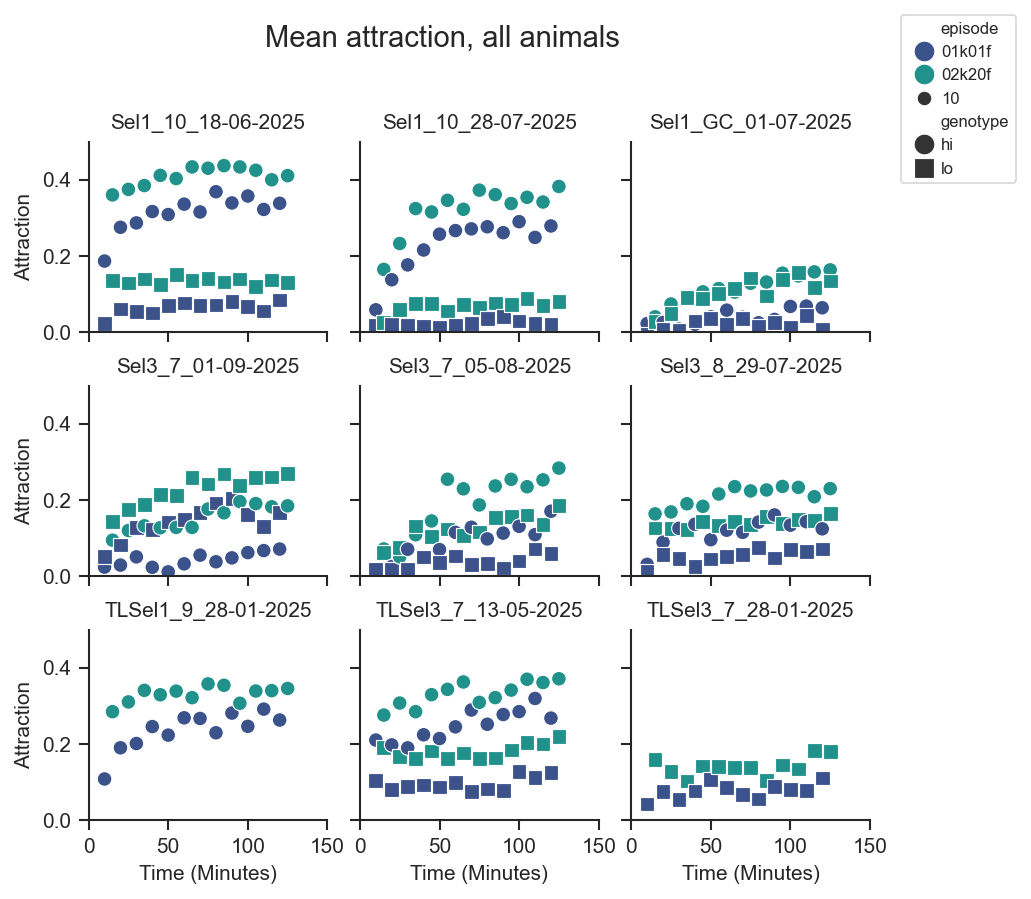

In [15]:
#dfPlot_filtered = dfPlot[dfPlot['genotype'] != 'esc']
dfPlot_filtered = dfPlot[~dfPlot['genotype'].str.contains(r'^(esc_(lo|hi)|na)$', regex=True)]


markers = {'hi': 'o', 'lo': 's'}  # adjust to your genotypes


g = sns.FacetGrid(
    dfPlot_filtered,
    col='lineSet',         # Facet by genotype (change as needed)
    col_wrap=3,             # Adjust for compactness
    sharex=True,
    sharey=True,
    height=2,
    aspect=1
)
g.map_dataframe(
    sns.scatterplot,
    x='inDishTime',
    y='mean',
    hue='episode',
    style='genotype',
    size=10,
    markers=markers,
    legend='full',

)
g.set(xlim=(0, 2.5*60), ylim=(0, .5))
g.set_axis_labels('Time (Minutes)', 'Attraction')
g.set_titles('{col_name}')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Mean attraction, all animals', fontsize=14)

# Remove the default legend and add a correct one
for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove() if hasattr(ax, "legend_") and ax.legend_ else None

# Add a single legend to the figure
handles, labels = g.axes[0].get_legend_handles_labels()
g.figure.legend(handles, labels, ncol=1, handletextpad=0, bbox_to_anchor=(1, 1), loc='upper left')

# Save the plot using the path variable
g.figure.savefig(os.path.join(outputDir, "attraction_linearvsbout.pdf"), bbox_inches="tight")

outputDir

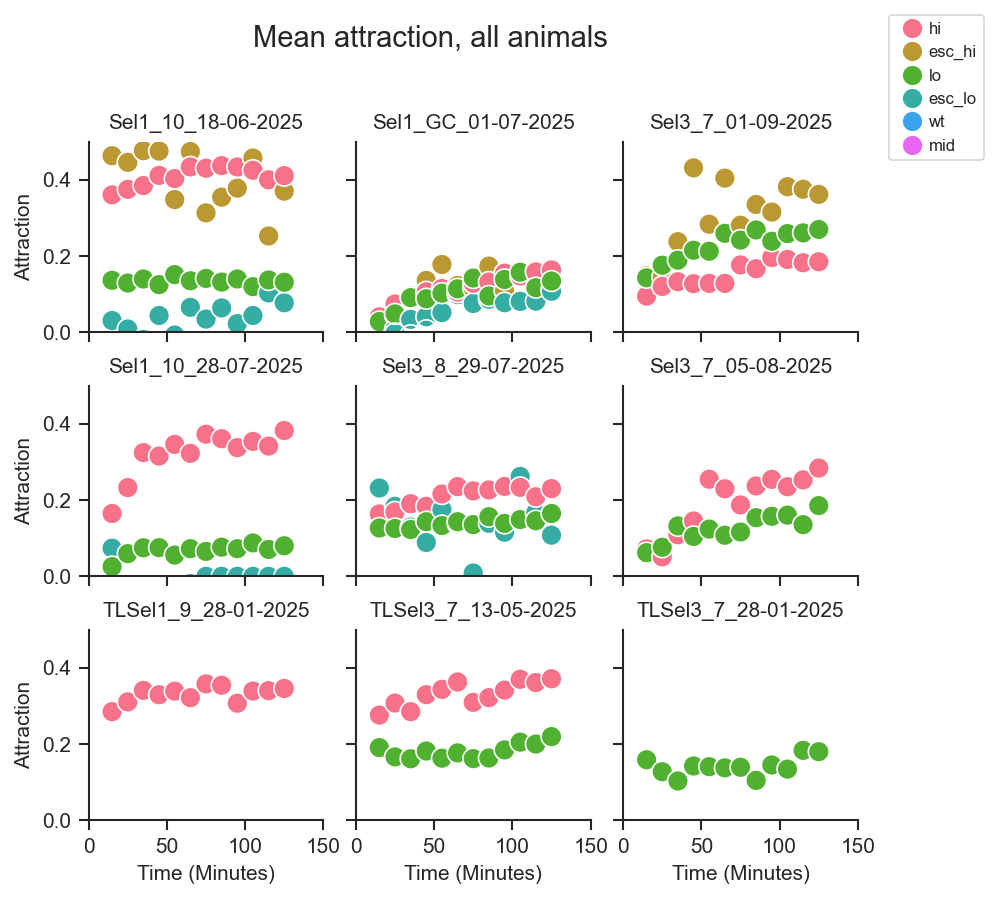

In [16]:
dfPlot_filtered2 = dfPlot[(dfPlot['genotype'] != 'esc') & (dfPlot['episode'] != '01k01f')]

g = sns.FacetGrid(
    dfPlot_filtered2,
    col='lineSet',         # Facet by genotype (change as needed)
    col_wrap=3,             # Adjust for compactness
    sharex=True,
    sharey=True,
    height=2,
    aspect=1
)
g.map_dataframe(
    sns.scatterplot,
    x='inDishTime',
    y='mean',
    hue='genotype',
    hue_order=["hi",'esc_hi', "lo",'esc_lo','wt','mid'],
    
)
g.set(xlim=(0, 2.5*60), ylim=(0, .5))
g.set_axis_labels('Time (Minutes)', 'Attraction')
g.set_titles('{col_name}')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Mean attraction, all animals', fontsize=14)

# Remove the default legend and add a correct one
for ax in g.axes.flatten():
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove() if hasattr(ax, "legend_") and ax.legend_ else None

# Add a single legend to the figure
handles, labels = g.axes[0].get_legend_handles_labels()
g.figure.legend(handles, labels, ncol=1, handletextpad=0, bbox_to_anchor=(1, 1), loc='upper left')

# Save the plot using the path variable
g.figure.savefig(os.path.join(outputDir, "attraction_hivslo.pdf"), bbox_inches="tight")



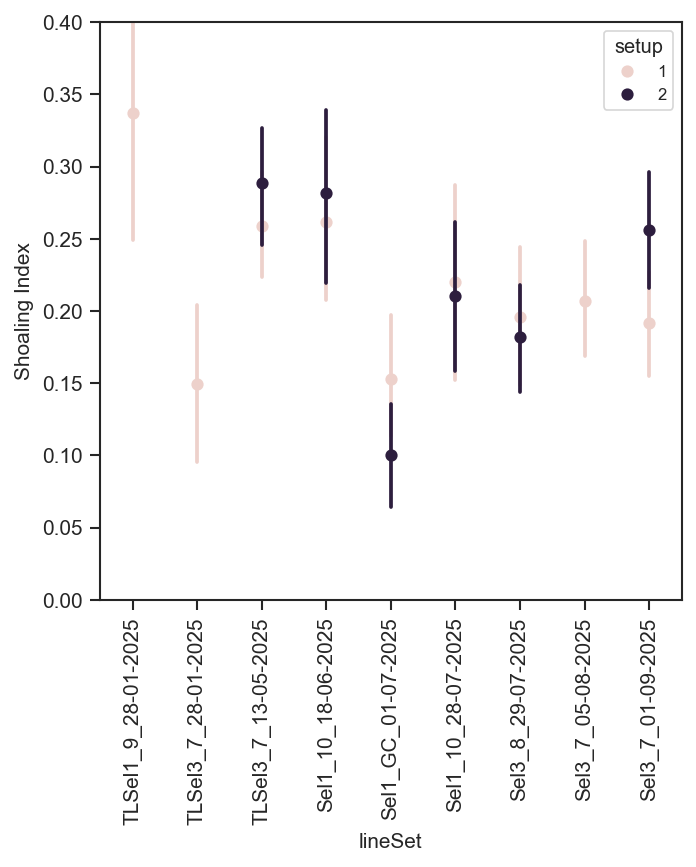

In [17]:
sns.pointplot(data=dfEpiAn[dfEpiAn.episode=='02k20f'],x='lineSet',y='si',hue='setup',linestyle='none')
plt.ylim([0,.4])
plt.xticks(rotation=90);
plt.ylabel('Shoaling Index');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "shoalindex_setups.pdf"), bbox_inches="tight")



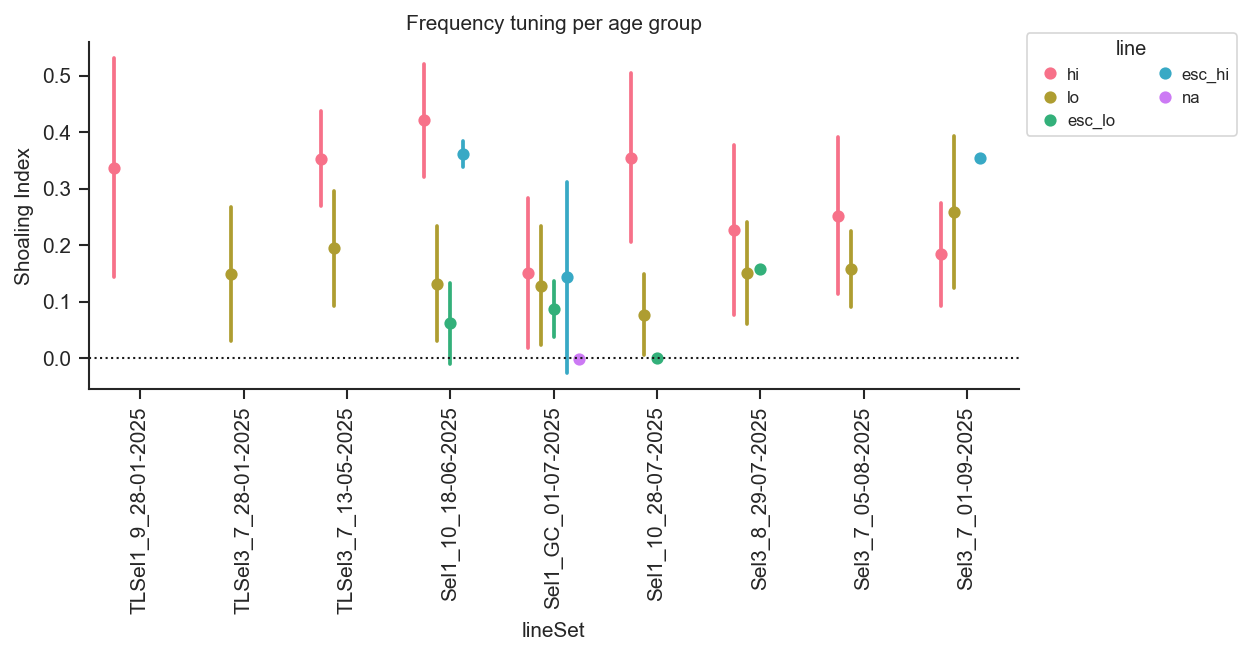

In [18]:
fig, axes = plt.subplots(figsize=(8,3))
sns.pointplot(data=dfEpiAn[dfEpiAn.episode=='02k20f'],
              x='lineSet',
              y='si',
              hue='genotype',
              
             linestyle='none',
             errorbar='sd',
             dodge=.5)
sns.despine()

axes.set_ylabel('Shoaling Index')
axes.axhline(0,ls=':',color='k')
axes.set_title('Frequency tuning per age group');
plt.legend(title='line',ncol=2,handletextpad=0,bbox_to_anchor=(1, 1.05))
plt.xticks(rotation=90);




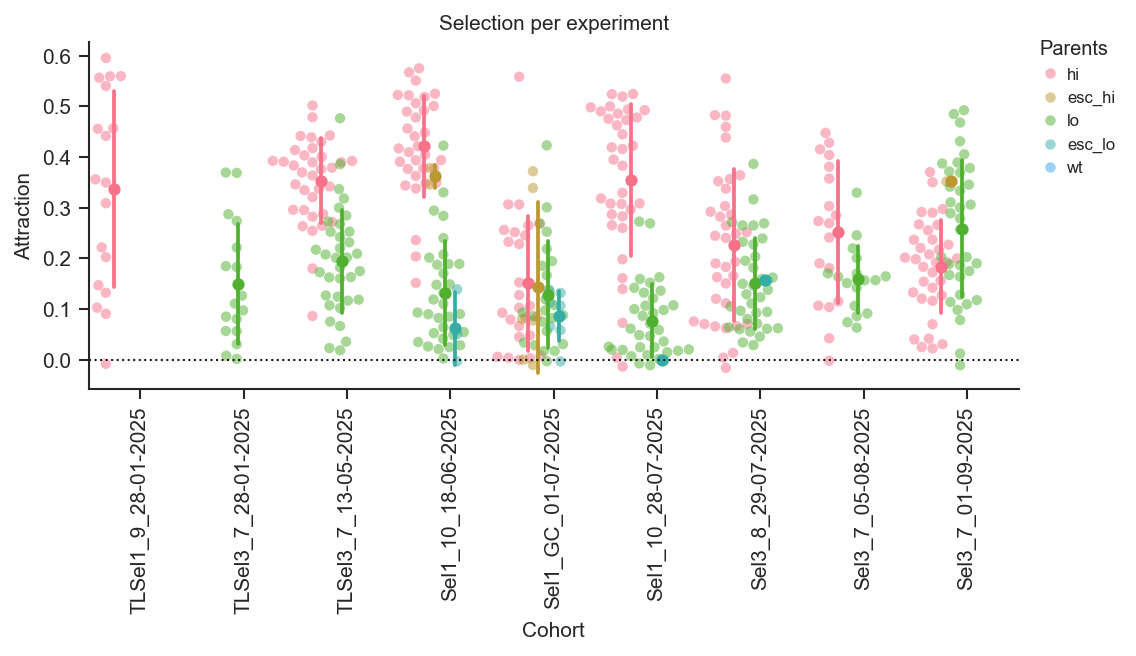

In [19]:
fig, axes = plt.subplots(figsize=(8, 3))
ix=(dfEpiAn.episode=='02k20f')#&(~dfEpiAn.lineSet.str.contains('_2_'))

selDat=dfEpiAn[ix]

allCat=selDat.lineSet.unique()
allCat.sort()
allCat=allCat[::-1]

sns.swarmplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              zorder=-1,
              dodge=.5,
              size=5,
              alpha=.5,
              #order=allCat,
             #hue_order=["hi", "lo",'wt','esc','mid'])
             hue_order=["hi",'esc_hi', "lo",'esc_lo','wt','mid'])

sns.pointplot(data=selDat,
              x='lineSet',
              y='si',
              hue='genotype',
              dodge=.5,
              linestyle='none',
              errorbar='sd',
              #hue_order=["hi", "lo",'wt','esc','mid'])
              hue_order=["hi",'esc_hi', "lo",'esc_lo','wt','mid'])


sns.despine()

axes.set_ylabel('Attraction')
axes.set_xlabel('Cohort')

axes.axhline(0,ls=':',color='k')
#axes.set_title('Selection F1');

plt.xticks(rotation=90);

handles, labels = axes.get_legend_handles_labels()

l = plt.legend(handles[0:5], labels[0:5], title='Parents',ncol=1,handletextpad=0,
               bbox_to_anchor=(1, 1.05),
              frameon=False)

#figPath=base+'SelectionAllToF1.png'
#plt.savefig(figPath,bbox_inches='tight')

plt.title('Selection per experiment');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "shoalindex_hivslo.pdf"), bbox_inches="tight")



# Generate Grid overview which animals to select

select one experimental condition to be analyzed and plotted based on lineSet as 'ShowGroup' below.
This will typically be from two setups.

In [20]:
dfEpiAn.lineSet.unique()

array(['TLSel1_9_28-01-2025', 'TLSel3_7_28-01-2025',
       'TLSel3_7_13-05-2025', 'Sel1_10_18-06-2025', 'Sel1_GC_01-07-2025',
       'Sel1_10_28-07-2025', 'Sel3_8_29-07-2025', 'Sel3_7_05-08-2025',
       'Sel3_7_01-09-2025'], dtype=object)

In [21]:
ShowGroup='Sel3_7_01-09-2025' # this is the group we want to select fish from
nSel=10 #how many fish to select, typically 10

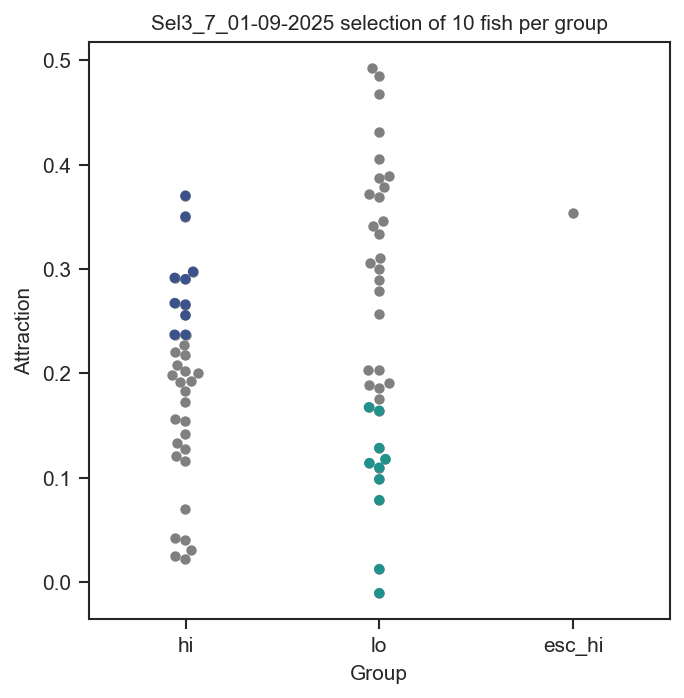

In [22]:
ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.lineSet==ShowGroup)

selDat=dfEpiAn[ix].copy()
selDat['plotGroup']=0

selDat['rank']=selDat.groupby(['lineSet','genotype'])['si'].rank()
selDat['rankInverse']=selDat.groupby(['lineSet','genotype'])['si'].rank(ascending=False)
selDat['pick']=((((selDat['rank']<=nSel)&(selDat['genotype']=='lo')) | ((selDat.rankInverse<=nSel)&(selDat['genotype']=='hi'))))


sns.swarmplot(selDat,x='genotype',y='si',color='gray');
sns.swarmplot(selDat[selDat['pick']==1 ],x='genotype',y='si',hue='genotype');
plt.title(ShowGroup + ' selection of ' + str(nSel) + ' fish per group');
plt.ylabel('Attraction');
plt.xlabel('Group');

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "selectfish_dots.pdf"), bbox_inches="tight")




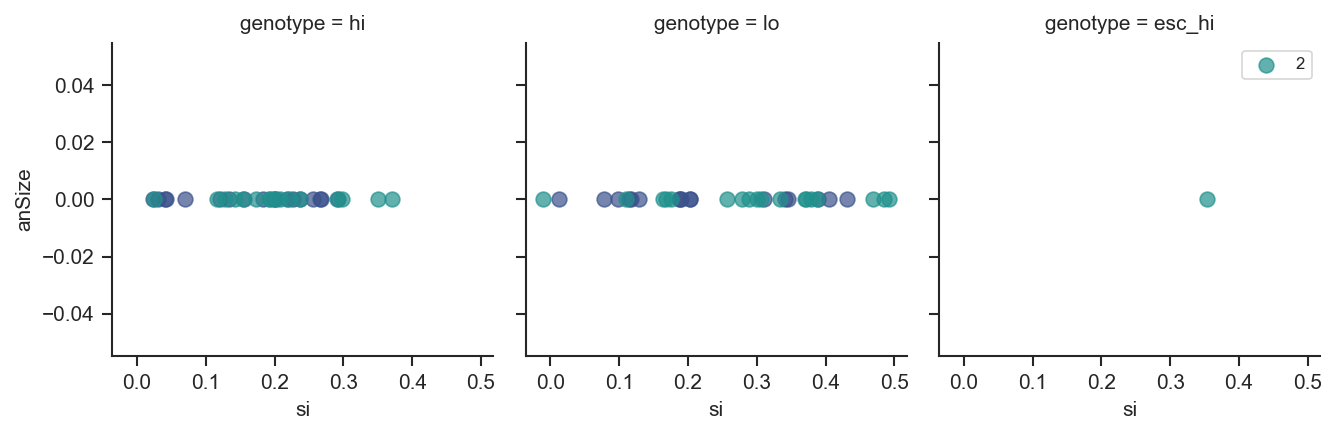

In [23]:
ix=(dfEpiAn.episode=='02k20f')&(dfEpiAn.lineSet==ShowGroup)
g=sns.FacetGrid(dfEpiAn[ix].groupby(['setup','animalID','genotype']).mean(numeric_only=True).reset_index(),col='genotype',hue='setup')
#g.set(xlim=(0,.5))

g=g.map(plt.scatter,'si','anSize',s=50,alpha=0.7)
plt.legend()

In [24]:
ixlo=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='lo')&(dfEpiAn.lineSet==ShowGroup)
dataLo=dfEpiAn[ixlo].groupby(['setup','animalID','genotype']).si.mean().reset_index()
dataLo['rank']=dataLo.si.rank()
dataLo=dataLo.sort_values(by='rank').reset_index()
dataLo

,index,setup,animalID,genotype,si,rank
0,20,2,6.0,lo,-0.010786,1.0
1,7,1,15.0,lo,0.012247,2.0
2,12,1,25.0,lo,0.078346,3.0
3,6,1,13.0,lo,0.098370,4.0
4,29,2,24.0,lo,0.109519,5.0
5,16,1,33.0,lo,0.113929,6.0
6,5,1,11.0,lo,0.117725,7.0
7,14,1,29.0,lo,0.128341,8.0
8,34,2,34.0,lo,0.164086,9.0
9,33,2,32.0,lo,0.167361,10.0


In [25]:

ixhi=(dfEpiAn.episode=='02k20f')&(dfEpiAn.genotype=='hi')&(dfEpiAn.lineSet==ShowGroup)
dataHi=dfEpiAn[ixhi].groupby(['setup','animalID','genotype']).si.mean(numeric_only=True).reset_index()
dataHi['rank']=dataHi.si.rank()
dataHi=dataHi.sort_values(by='rank',ascending =False).reset_index()
dataHi

,index,setup,animalID,genotype,si,rank
0,19,2,3.0,hi,0.370292,34.0
1,28,2,23.0,hi,0.350268,33.0
2,30,2,27.0,hi,0.297468,32.0
3,3,1,6.0,hi,0.291511,31.0
4,21,2,9.0,hi,0.290250,30.0
5,2,1,4.0,hi,0.267259,29.0
6,10,1,20.0,hi,0.265929,28.0
7,11,1,22.0,hi,0.255627,27.0
8,22,2,11.0,hi,0.236972,26.0
9,0,1,0.0,hi,0.236951,25.0


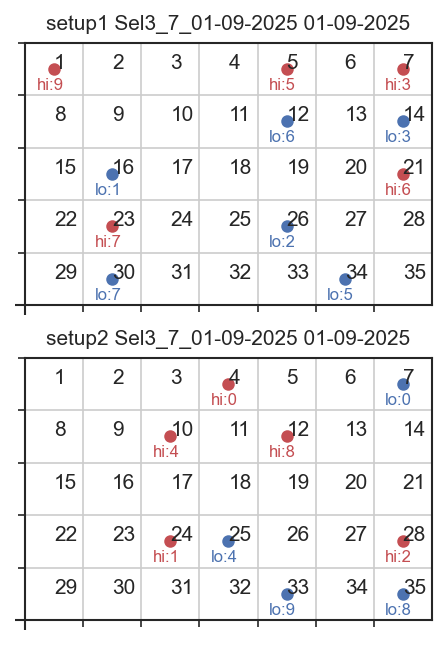

In [26]:
fig, axes = plt.subplots(2,1,figsize=(3.5, 5))


major_ticks = np.arange(0, 7, 7)
minor_ticks = np.arange(0, 7, 1)



for n,ax in enumerate(axes):
    for i in range(35):
        ax.text(i%7+.5,4-np.floor_divide(i,7)+.5,str(i+1))
        
    
    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_yticks(major_ticks)
    ax.set_yticks(minor_ticks, minor=True)

    ax.set_xlim([0,7])
    ax.set_ylim([0,5])
    ax.grid(which='both')
    ax.tick_params(labelbottom=False)    
    ax.tick_params(labelleft=False)  
    
for n,row in dataHi[:nSel].iterrows():
    a=int(row.setup==2)
    i=row.animalID
    axes[a].plot(i%7+.5,4-np.floor_divide(i,7)+.5,'r.')
    axes[a].text(i%7+.2,4-np.floor_divide(i,7)+.1,'hi:'+str(n),color='r',fontsize=8)

for n,row in dataLo[:nSel].iterrows():
    a=int(row.setup==2)
    i=row.animalID
    axes[a].plot(i%7+.5,4-np.floor_divide(i,7)+.5,'b.')
    axes[a].text(i%7+.2,4-np.floor_divide(i,7)+.1,'lo:'+str(n),color='b',fontsize=8)
    

axes[0].set_title('setup1 '+ShowGroup + ' ' +dfEpiAn[ixhi].date.unique()[0]);
axes[1].set_title('setup2 '+ShowGroup + ' ' +dfEpiAn[ixhi].date.unique()[0]);

# Save the plot using the path variable
plt.savefig(os.path.join(outputDir, "selectfish_grid.pdf"), bbox_inches="tight")


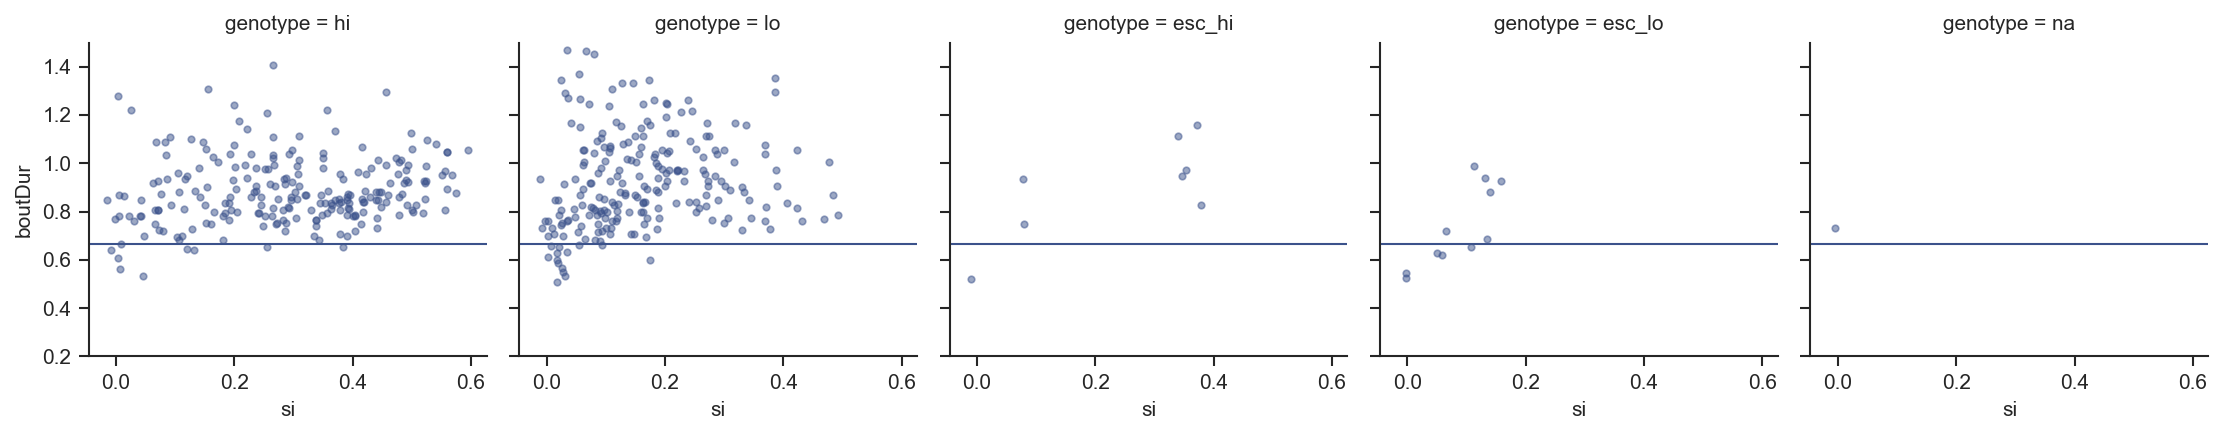

In [27]:
ix=(dfEpiAn.episode=='02k20f')
g=sns.FacetGrid(dfEpiAn[ix].groupby(['setup','animalID','genotype','lineSet']).mean(numeric_only=True).reset_index(),col='genotype')
g=g.map(plt.scatter,'si','boutDur',s=10,alpha=0.5)
for ax in g.axes.ravel():
    ax.set_ylim([0.2,1.5])
    ax.axhline(20/30)
#figPath=base+'SelectionSizeVsShoal.png'
#plt.savefig(figPath,bbox_inches='tight')


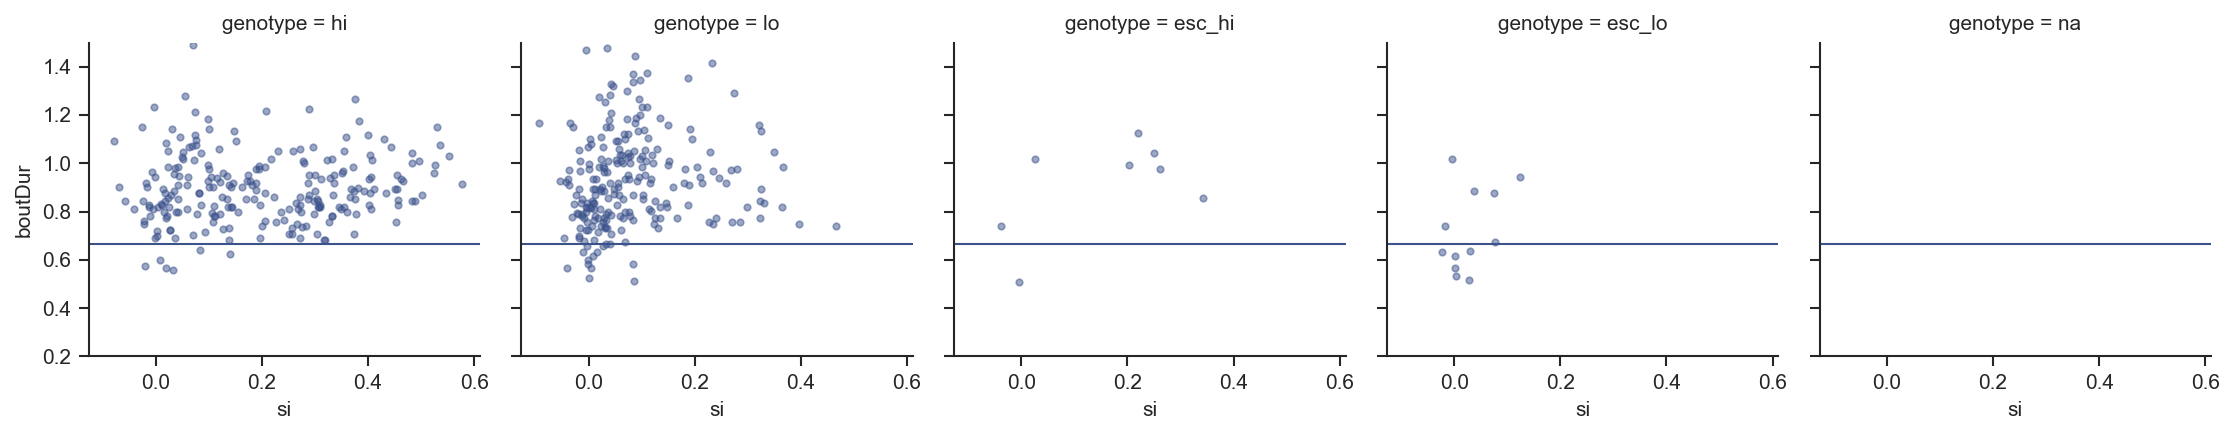

In [28]:
ix=(dfEpiAn.episode=='01k01f')
g=sns.FacetGrid(dfEpiAn[ix].groupby(['setup','animalID','genotype','lineSet']).mean(numeric_only=True).reset_index(),col='genotype')
g=g.map(plt.scatter,'si','boutDur',s=10,alpha=0.5)
for ax in g.axes.ravel():
    ax.set_ylim([0.2,1.5])
    ax.axhline(20/30)